### Libraries

In [1]:
import numpy as np
import pandas as pd
import random

from scipy.optimize import root
from scipy.stats import multivariate_normal
from scipy.spatial import Voronoi, voronoi_plot_2d

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from kmeans_explainer import CFE_explainer

from time import process_time

### Globals

In [2]:
random_seed = 42

### Create dataset

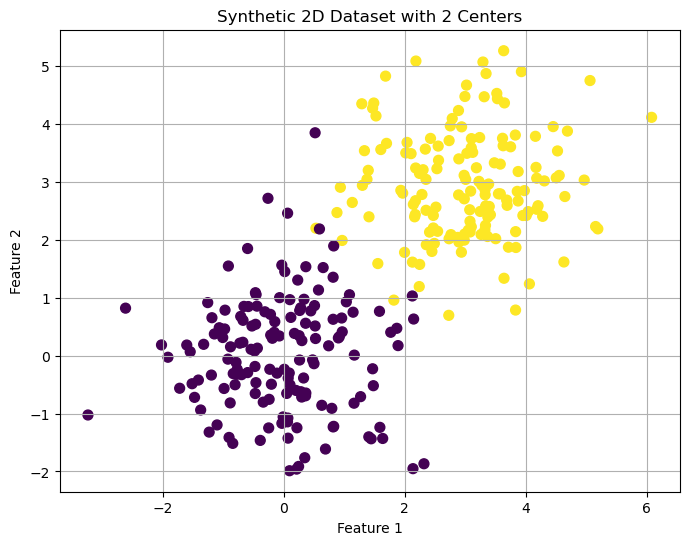

In [3]:
centers = np.array([[0.0, 0.0], [3.0, 3.0]])
n_samples = 300


# Generate synthetic 2D data
X, y = make_blobs(n_samples=n_samples, centers=centers, random_state=random_seed)
    
# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
plt.title(f'Synthetic 2D Dataset with {len(centers)} Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### Fit $k$-means algorithm

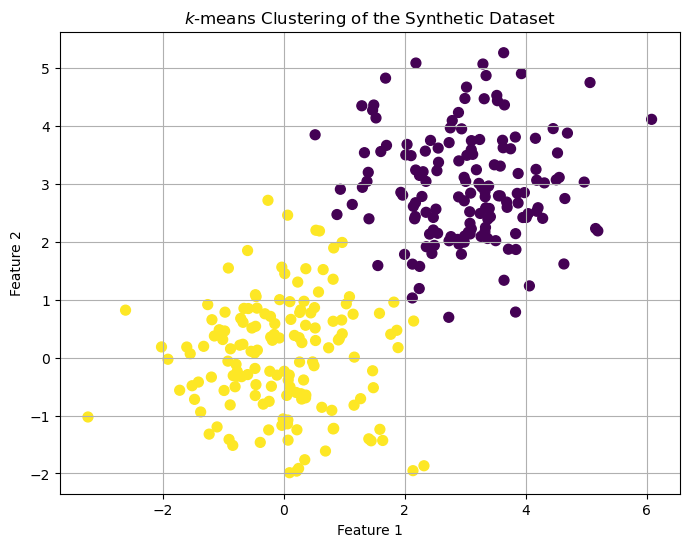

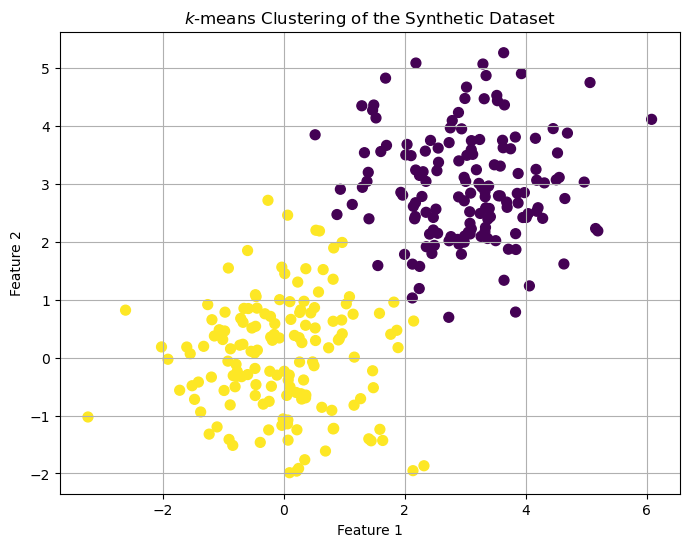

In [4]:
kmeans = KMeans(n_clusters=2, random_state=random_seed)
kmeans.fit(X)

# Predict the labels (clusters) for the data points
kmeans_labels = kmeans.predict(X)

# Plot the original dataset and GMM clusters
plt.figure(figsize=(8, 6))

# Scatter plot of the data colored by the GMM predicted labels
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50, marker='o', label='$k$-means clusters')
plt.title('$k$-means Clustering of the Synthetic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

### Save dataset

In [5]:
# Create a pandas DataFrame with the X and Y coordinates and the predicted GMM cluster labels
data = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    #'z': X[:, 2],
    'c_label': kmeans_labels
})

# Save the DataFrame to a CSV file
data.to_csv('./data.csv', index=False)

### Create factuals uniformly at random

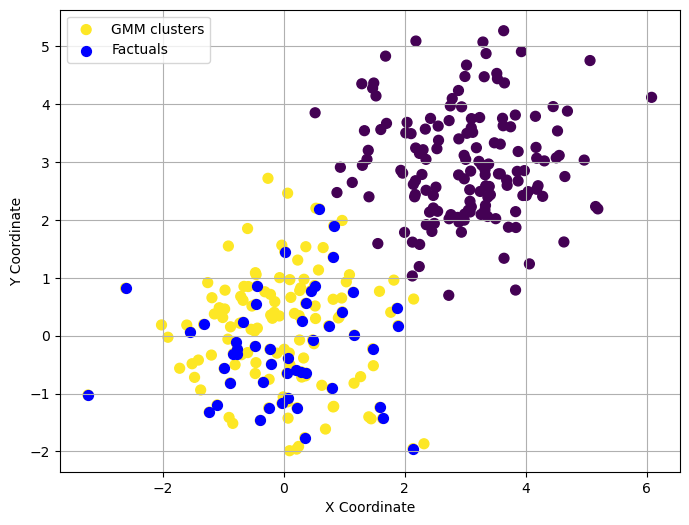

In [6]:
np.random.seed(random_seed)

# Number of samples and bounds
n_factuals = 50

sampled_indexes = np.random.choice(np.where(kmeans_labels == 1)[0], size=n_factuals, replace=False)

np_factuals = X[sampled_indexes]

# Compute distance from enemy center
distances = np.linalg.norm(np_factuals - centers[1], axis=1)
sorted_indices = np.argsort(distances)
distances = distances[sorted_indices]
np_factuals = np_factuals[sorted_indices]

# Plot the uniformly distributed data
plt.figure(figsize=(8, 6))
# plt.title(f'Uniformly Distributed 2D Points (n={n_factuals})')
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50, marker='o', label='GMM clusters')
plt.scatter(np_factuals[:, 0], np_factuals[:, 1], c='blue', s=50, marker='o', label='Factuals')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

plt.grid(True)
plt.legend()
plt.show()

### Save factuals

In [7]:
df_factuals = pd.DataFrame({
    'x': np_factuals[:, 0],
    'y': np_factuals[:, 1],
    #'z': np_factuals[:, 2],
    'distance': distances,
    'c_label': kmeans.predict(np_factuals),
})

In [8]:
# Save the DataFrame to a CSV file
df_factuals.to_csv('./factuals.csv', index=False)

### Hyperparameters

In [9]:
cfes_list = list()
time_list = list()

# Factual
# x_init = np.array([1, 1])


# allowed features to change
mask = np.array([1, 1])

# Epsilon penalty
d_eps_center_dist_ratio = 0.0

# Computed clusters' centers
m1, m2 = kmeans.cluster_centers_

explainer = CFE_explainer(m1, m2)

### Method

In [10]:
for factual in np_factuals:
    t_start = process_time() 
    z_optimal = explainer.compute_counterfactual(factual, mask, d_eps_center_dist_ratio)
    t_stop = process_time()
    time_list.append(t_stop - t_start)
    cfes_list.append(z_optimal)

### Plots

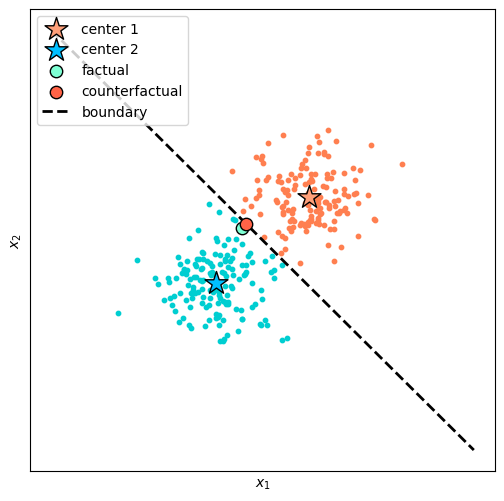

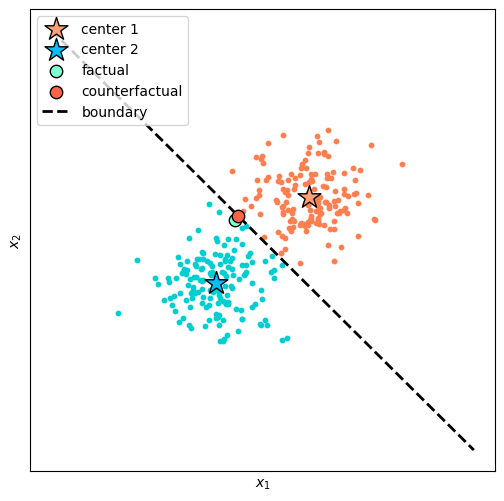

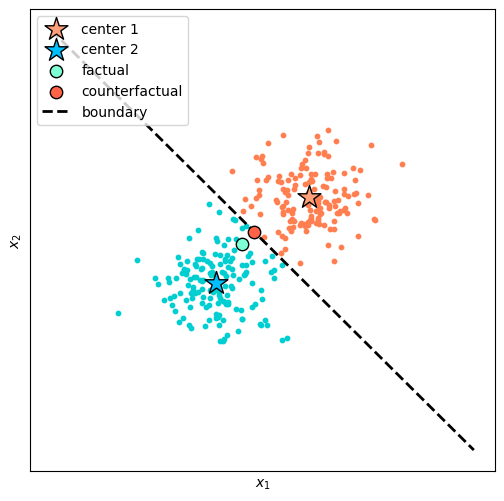

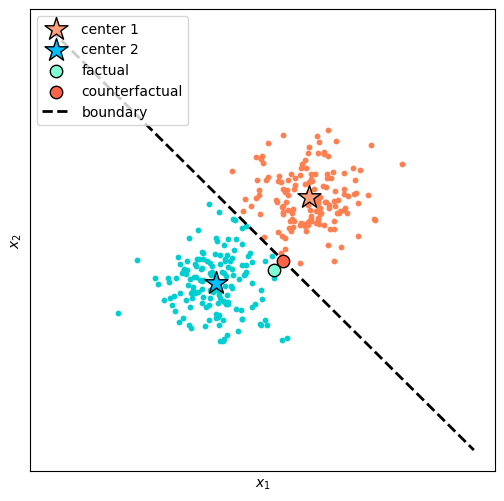

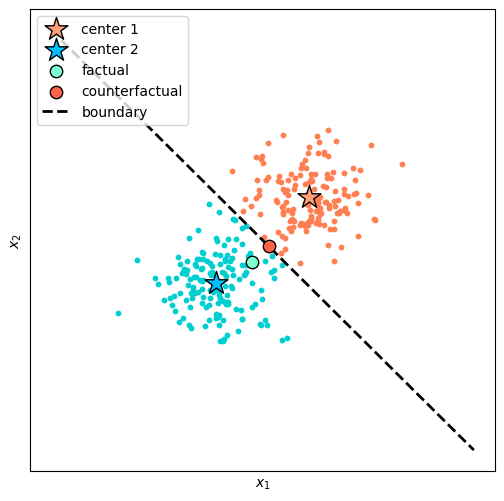

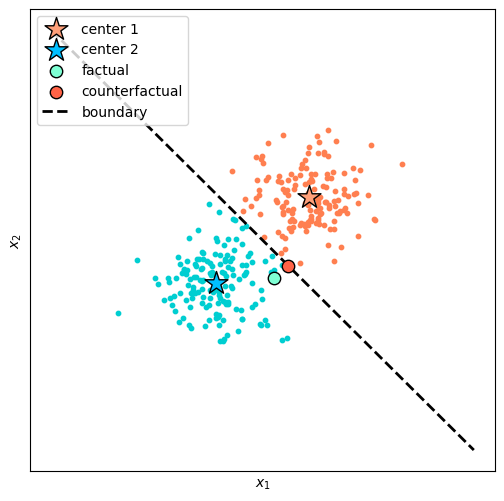

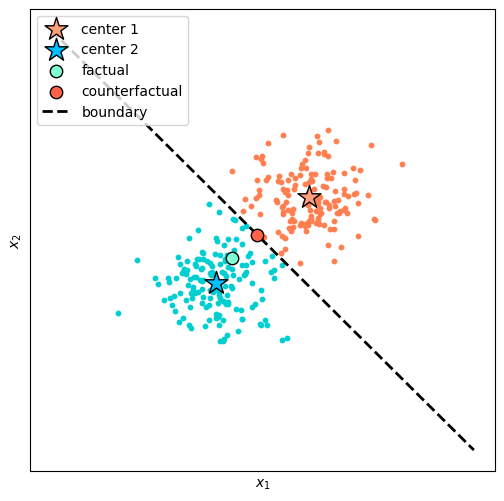

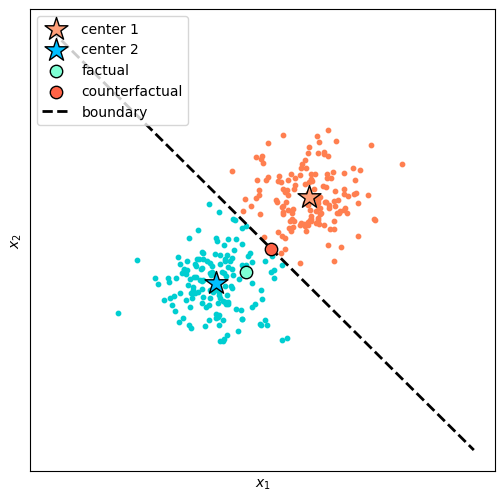

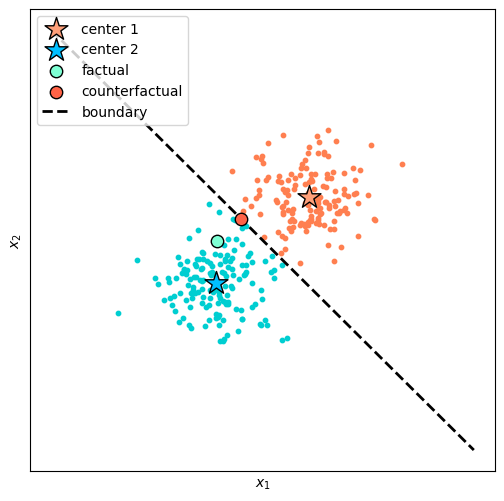

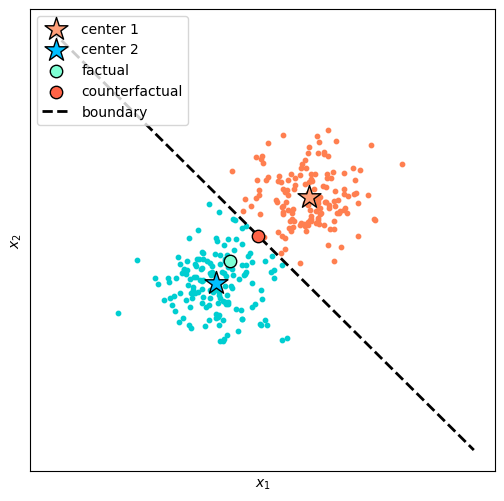

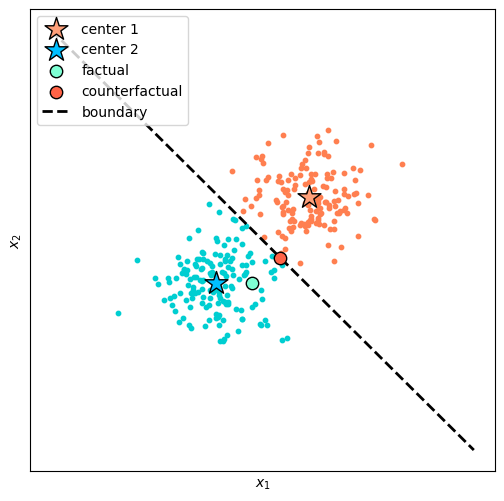

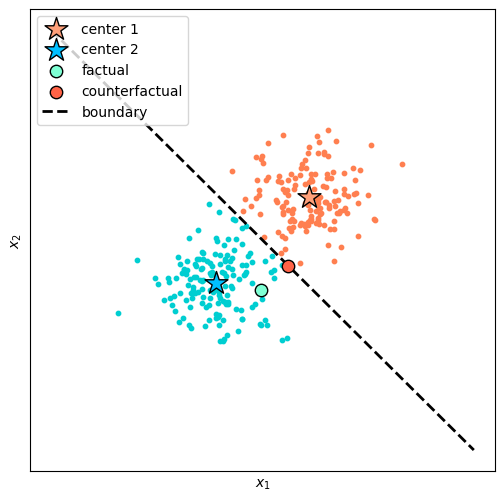

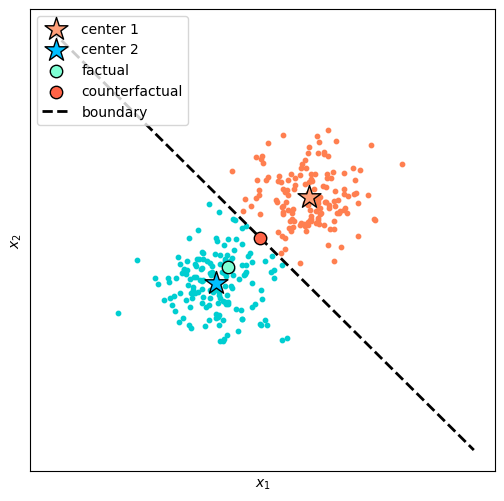

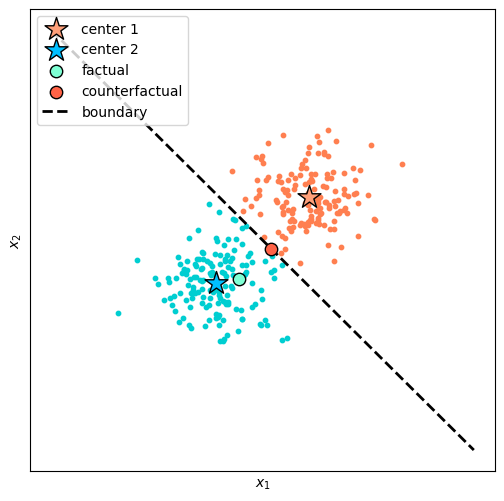

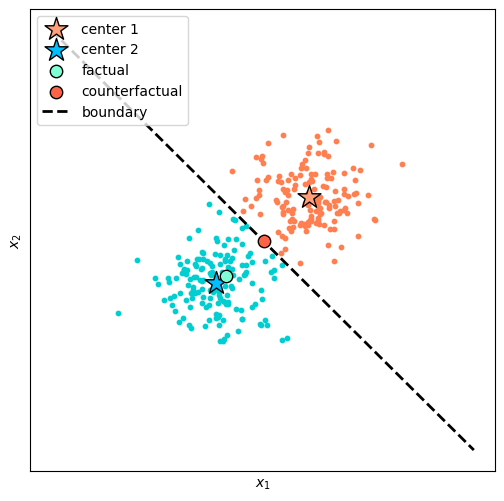

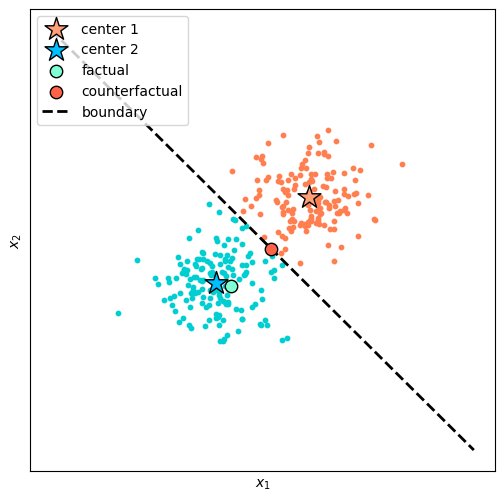

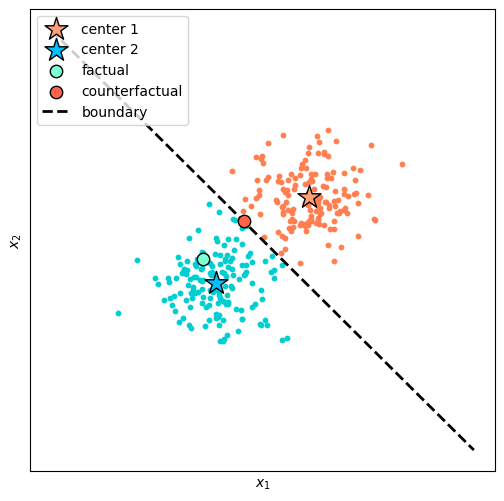

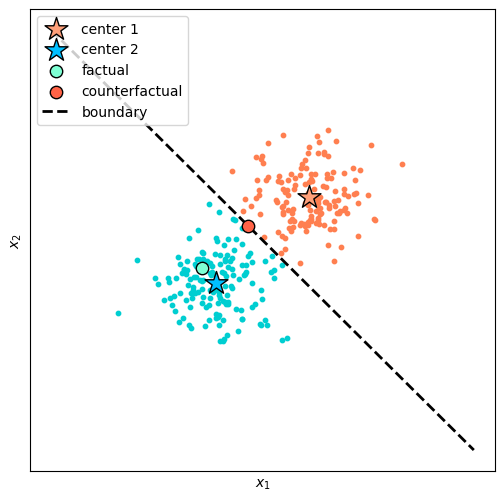

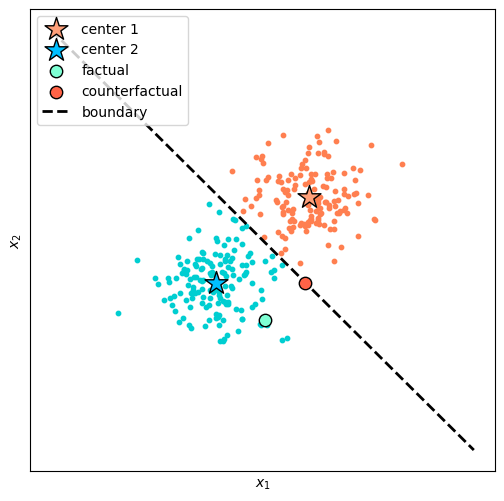

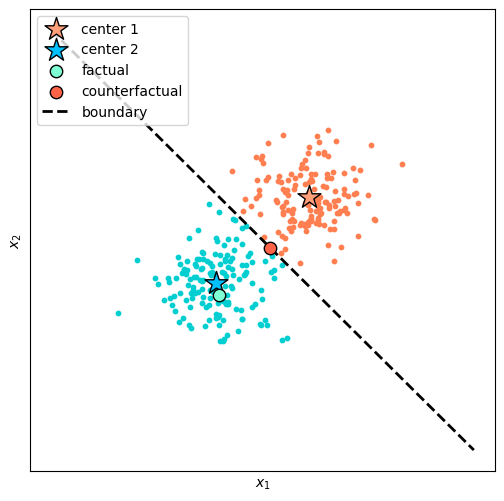

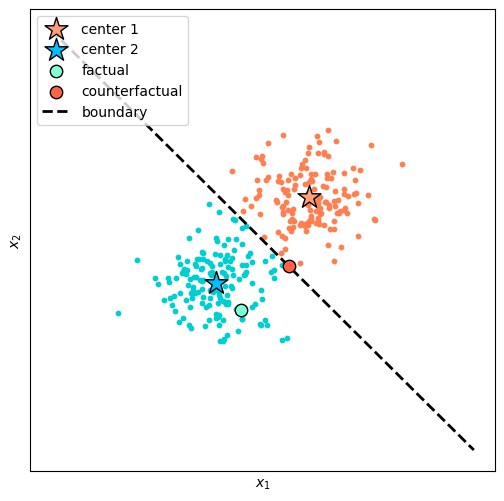

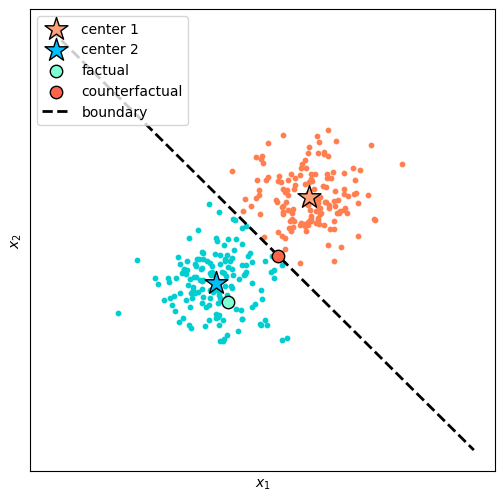

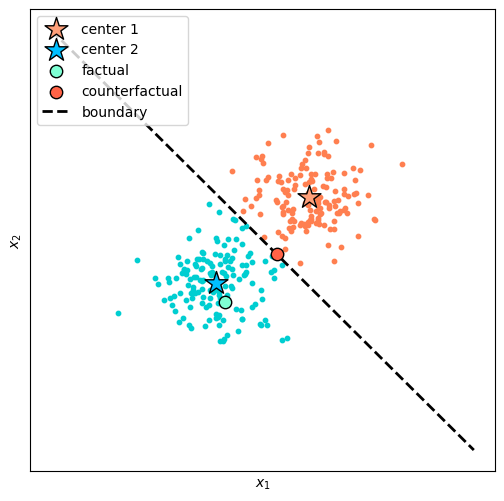

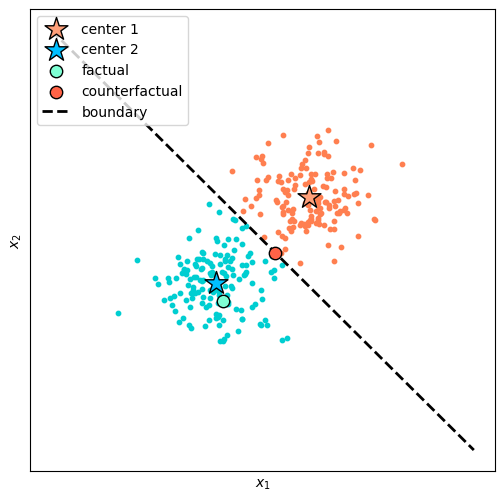

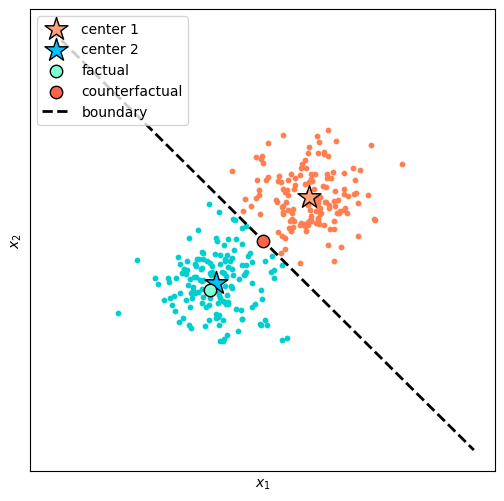

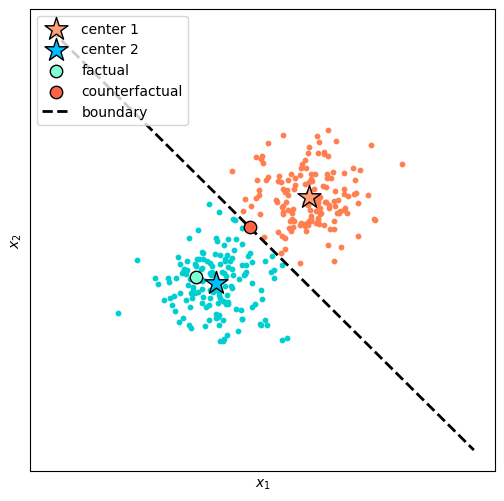

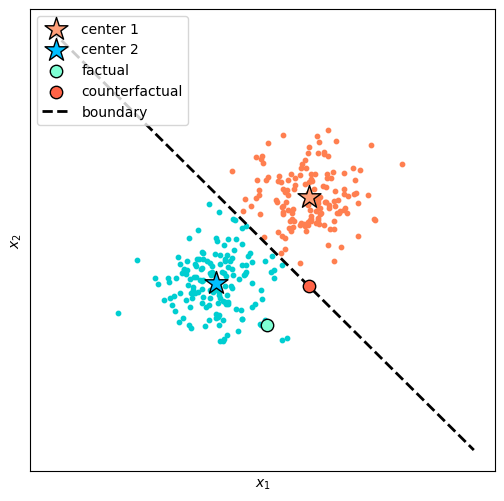

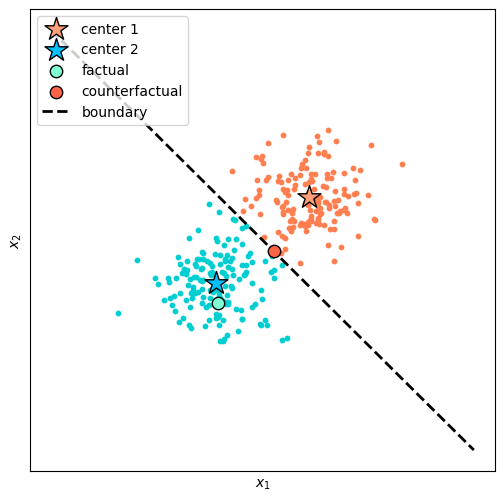

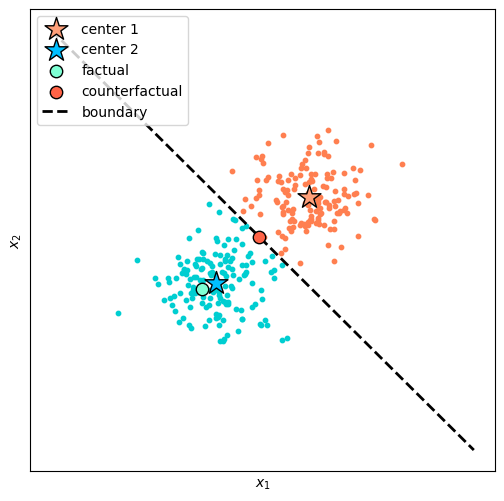

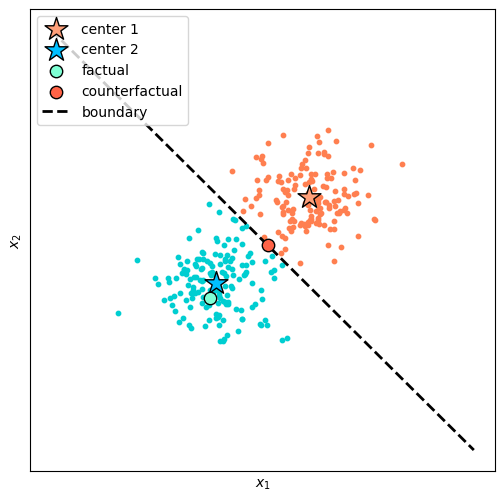

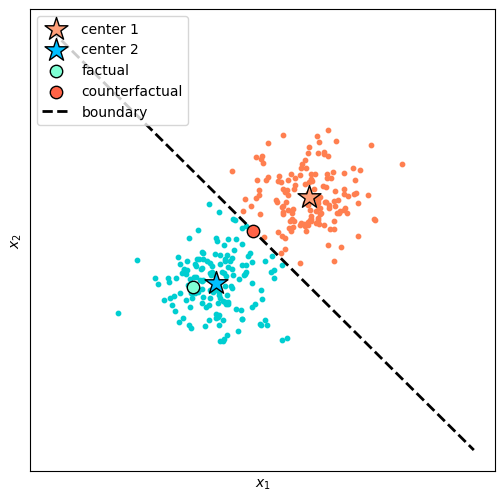

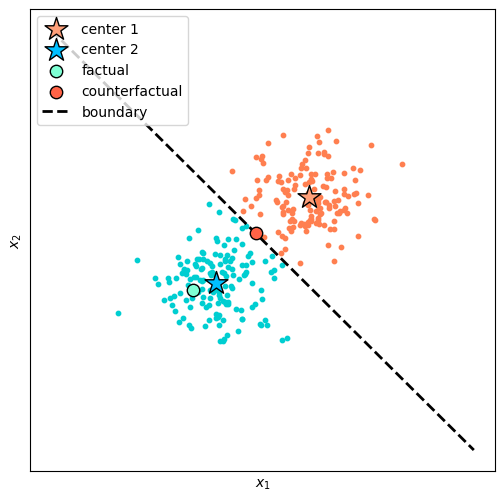

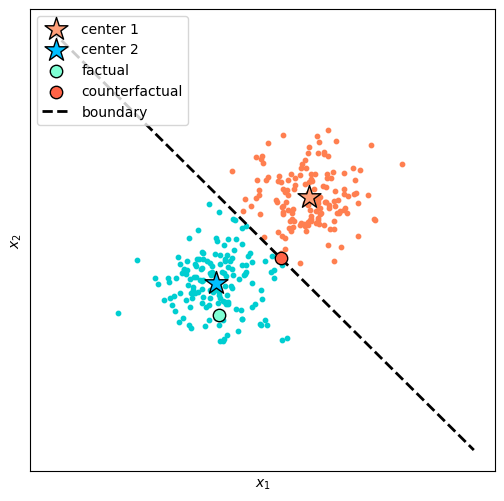

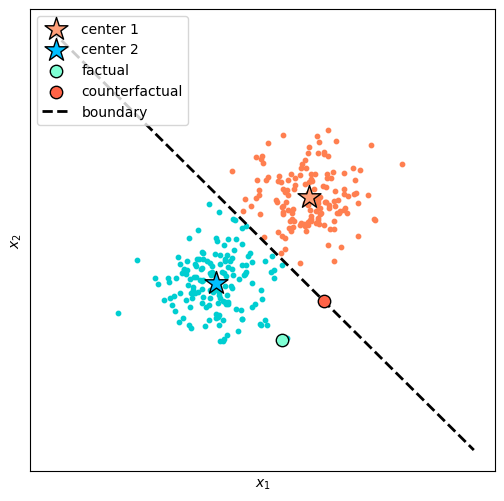

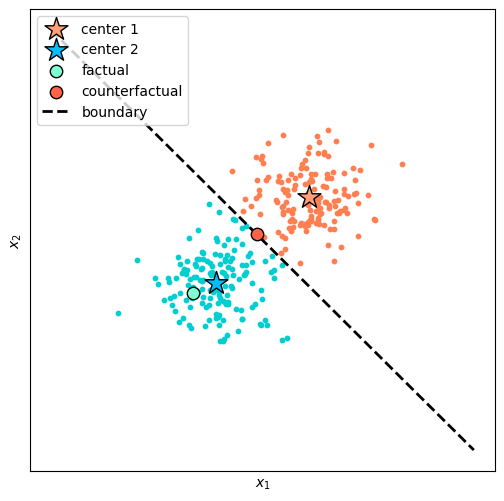

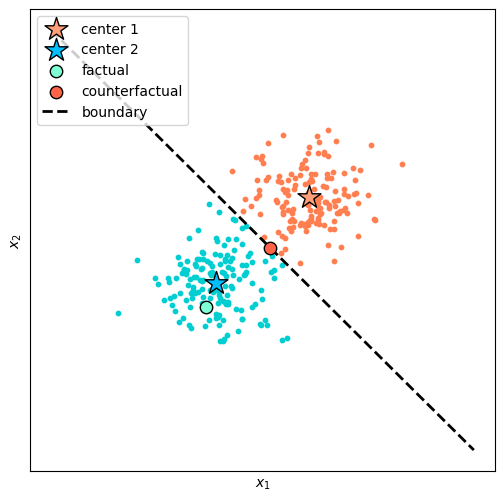

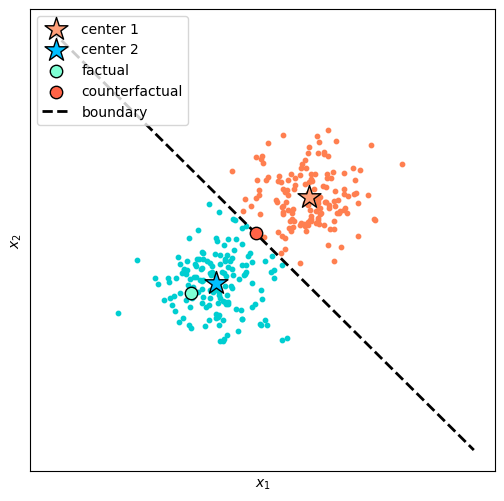

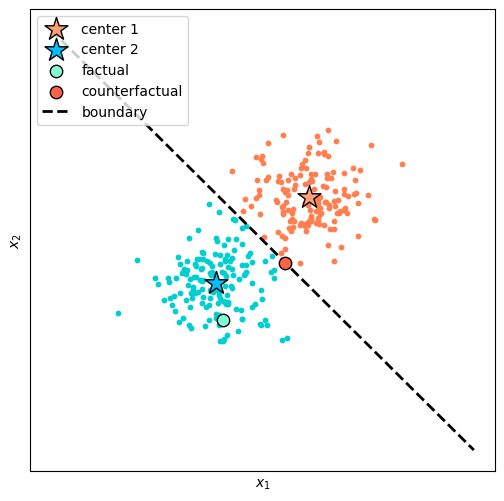

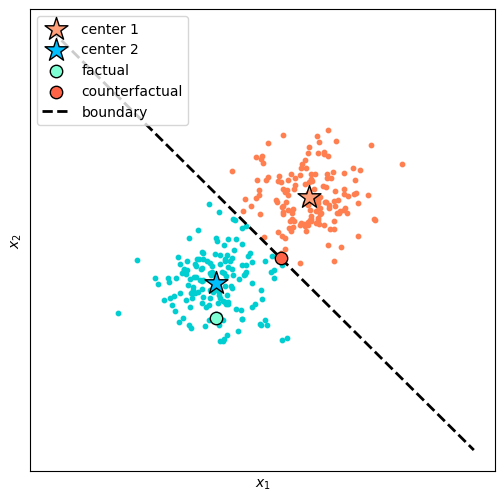

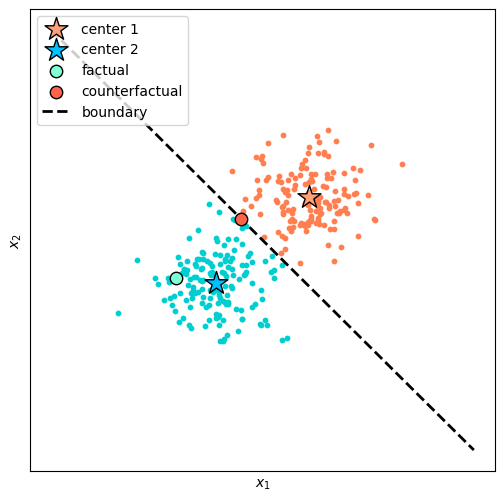

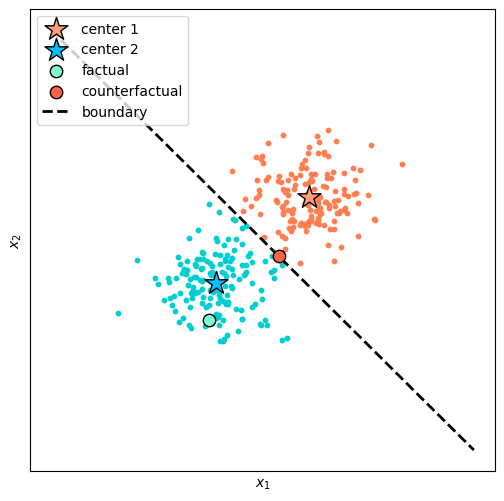

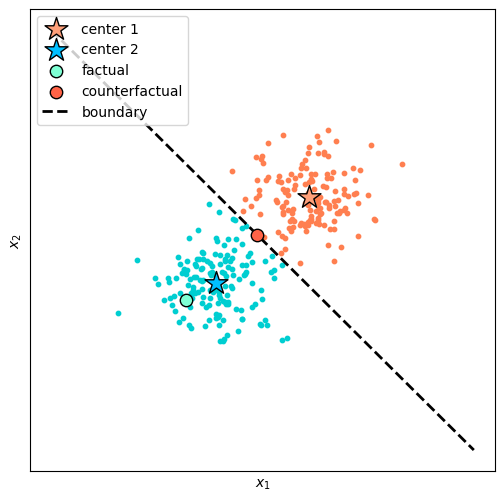

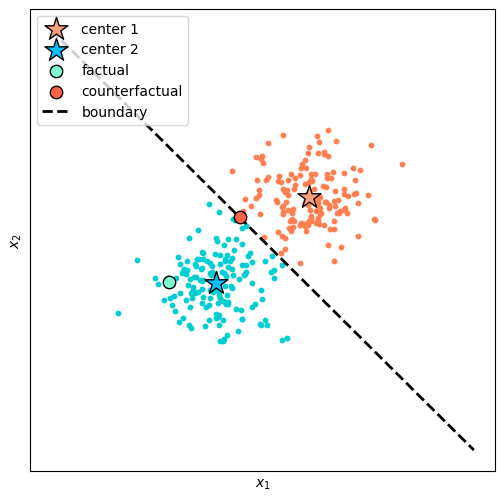

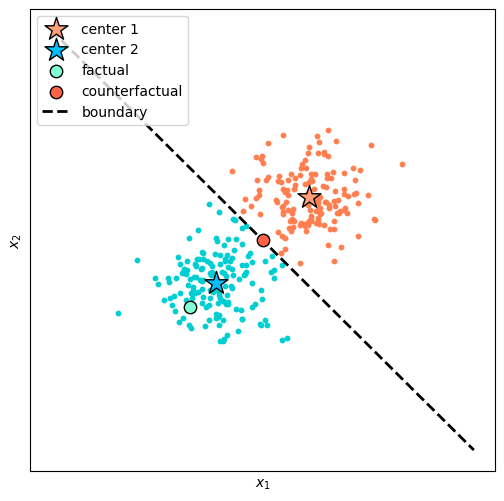

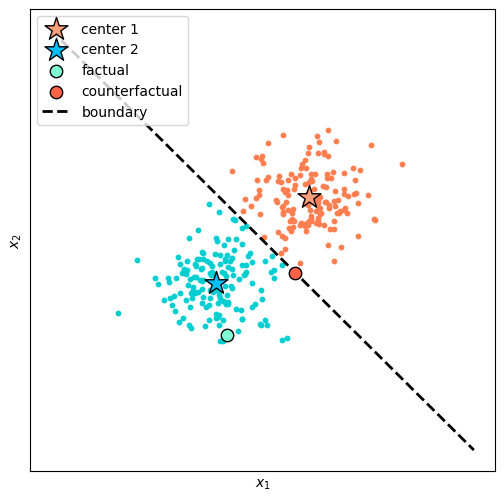

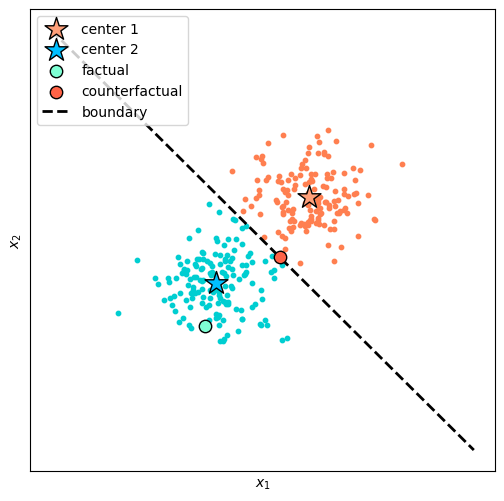

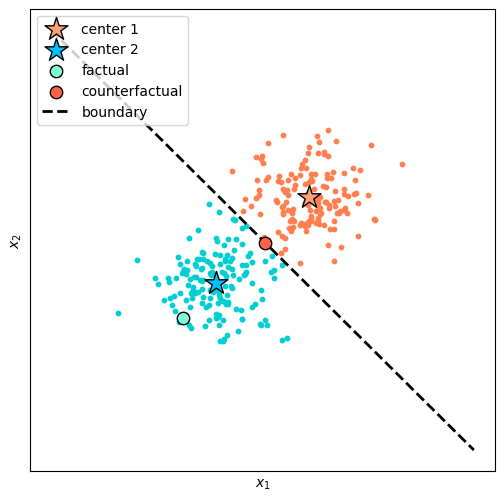

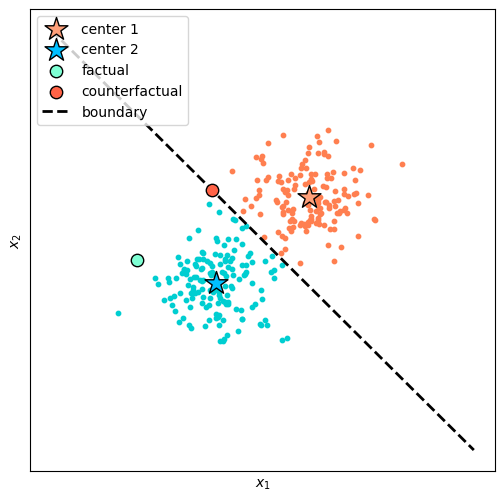

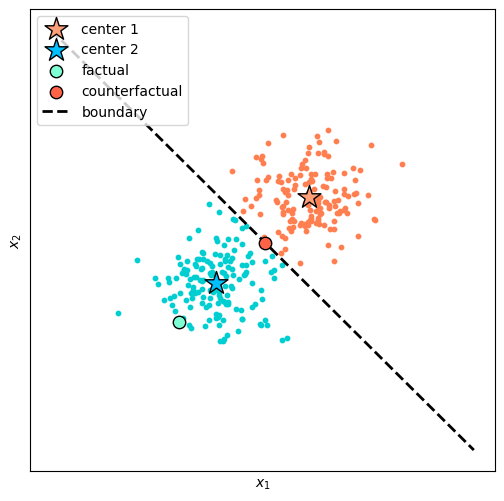

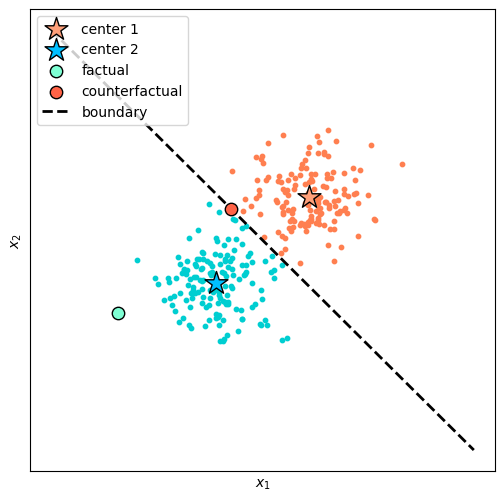

In [11]:
for i, z_optimal in enumerate(cfes_list):
    # Create a grid of points
    x, y = np.mgrid[-4:6:.01, -4:6:.01]
    pos = np.dstack((x, y))

    # Calculate the midpoint for the hyperplane
    midpoint = (m1 + m2) / 2

    # Calculate the direction vector from m1 to m2
    direction = (m2 - m1)

    # Calculate the orthogonal vector
    orthogonal_direction = np.array([-direction[1], direction[0]])  # Perpendicular vector

    # Normalize the orthogonal direction for consistent plotting
    orthogonal_direction = orthogonal_direction / np.linalg.norm(orthogonal_direction)

    # Define the line in the direction of the orthogonal vector
    # Extend the line by a certain factor
    length = 10 # Length of the line segment in each direction
    x_line = np.array([midpoint[0] - length * orthogonal_direction[0], 
                       midpoint[0] + length * orthogonal_direction[0]])
    y_line = np.array([midpoint[1] - length * orthogonal_direction[1], 
                       midpoint[1] + length * orthogonal_direction[1]])

    # Plot the pdfs and the vectors
    plt.figure(figsize=(6, 6))

    # Scatter plots for the vectors
    c_1_indexes = np.where(kmeans_labels==1)
    c_2_indexes = np.where(kmeans_labels==0)
    plt.scatter(X[c_1_indexes, 0], X[c_1_indexes, 1], s=10, c='darkturquoise', zorder=0)
    plt.scatter(X[c_2_indexes, 0], X[c_2_indexes, 1], s=10, c='coral', zorder=0)

    plt.scatter(m1[0], m1[1], c='lightsalmon', marker='*', label='center 1', s=300, edgecolors='black')
    plt.scatter(m2[0], m2[1], c='deepskyblue', marker='*', label='center 2', s=300, edgecolors='black')
    plt.scatter(np_factuals[i][0], np_factuals[i][1], c='aquamarine', marker='o', label='factual', s=80, edgecolors='black')
    plt.scatter(z_optimal[0], z_optimal[1], c='tomato', marker='o', label='counterfactual', s=80, edgecolors='black')
    # Add the orthogonal hyperplane to the plot
    plt.plot(x_line, y_line, c='black', label='boundary', linewidth=2, linestyle='--', zorder=0)

    plt.legend(loc='upper left')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    # plt.title('Seperating Hyperplane')
    plt.grid(False)
    #plt.xlim([-4, 6])
    #plt.ylim([-4, 6])
    plt.xticks([])
    plt.yticks([])
    plt.show()

### Save counterfactuals

In [12]:
counter_factuals = np.array(cfes_list)

data = pd.DataFrame({
    'x': counter_factuals[:, 0],
    'y': counter_factuals[:, 1],
    # 'c_label': gmm.predict(counter_factuals)
})

# Save the DataFrame to a CSV file
data.to_csv('./counter_factuals.csv', index=False)

### Plots

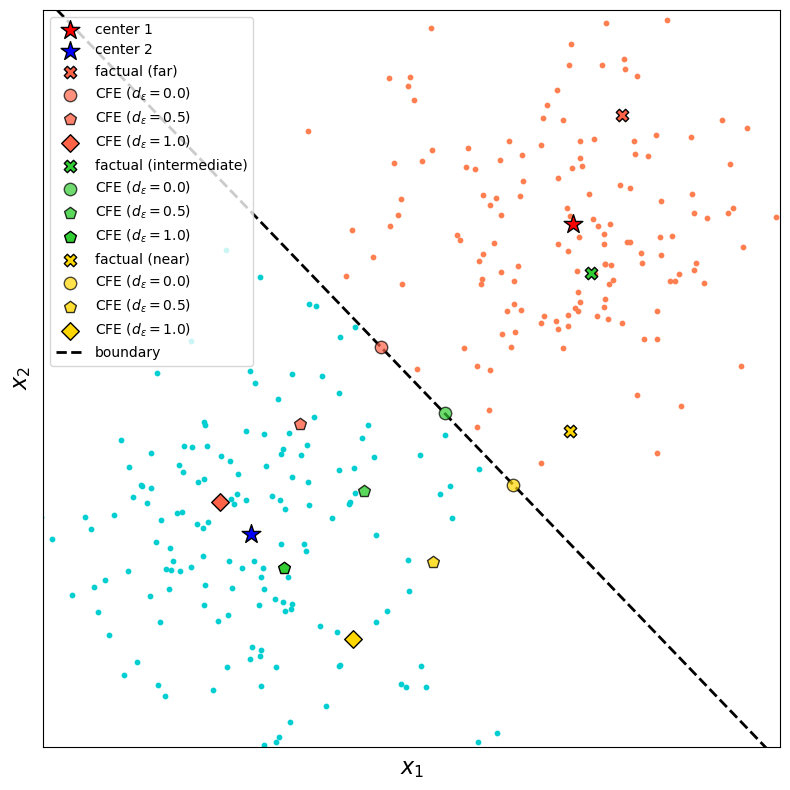

In [29]:
# Create a grid for plotting the pdfs
x, y = np.mgrid[-4:6:.01, -4:6:.01]
pos = np.dstack((x, y))

# Plot the pdfs and the vectors
plt.figure(figsize=(8, 8))

# Scatter plots for the vectors
c_1_indexes = np.where(kmeans_labels==1)
c_2_indexes = np.where(kmeans_labels==0)
plt.scatter(X[c_1_indexes, 0], X[c_1_indexes, 1], s=10, c='darkturquoise', zorder=0)
plt.scatter(X[c_2_indexes, 0], X[c_2_indexes, 1], s=10, c='coral', zorder=0)

# Scatter plots for the vectors
plt.scatter(m1[0], m1[1], c='r', marker='*', label='center 1', s=200, edgecolors='black')
plt.scatter(m2[0], m2[1], c='b', marker='*', label='center 2', s=200, edgecolors='black')

# Far
factual_far = np.array([3.5, 4])
cfe_far = explainer.compute_counterfactual(factual_far, mask, d_eps_center_dist_ratio=0)
plt.scatter(factual_far[0], factual_far[1], c='tomato', marker='X', label='factual (far)', s=80, edgecolors='black')
plt.scatter(cfe_far[0], cfe_far[1], c='tomato', marker='o', alpha=0.7, label='CFE ($d_\epsilon = 0.0$)', s=80, edgecolors='black')

cfe_far_50 = explainer.compute_counterfactual(factual_far, mask, d_eps_center_dist_ratio=0.5)
plt.scatter(cfe_far_50[0], cfe_far_50[1], c='tomato', marker='p', alpha=0.8, label='CFE ($d_\epsilon = 0.5$)', s=80, edgecolors='black')

cfe_far_100 = explainer.compute_counterfactual(factual_far, mask, d_eps_center_dist_ratio=1.0)
plt.scatter(cfe_far_100[0], cfe_far_100[1], c='tomato', marker='D', alpha=1.0, label='CFE ($d_\epsilon = 1.0$)', s=80, edgecolors='black')


# Intermidiate
factual_interm = np.array([3.2, 2.5])
cfe_interm = explainer.compute_counterfactual(factual_interm, mask, d_eps_center_dist_ratio=0)
plt.scatter(factual_interm[0], factual_interm[1], c='limegreen', marker='X', label='factual (intermediate)', s=80, edgecolors='black')
plt.scatter(cfe_interm[0], cfe_interm[1], c='limegreen', marker='o', alpha=0.7, label='CFE ($d_\epsilon = 0.0$)', s=80, edgecolors='black')

cfe_interm_50 = explainer.compute_counterfactual(factual_interm, mask, d_eps_center_dist_ratio=0.5)
plt.scatter(cfe_interm_50[0], cfe_interm_50[1], c='limegreen', marker='p', alpha=0.8, label='CFE ($d_\epsilon = 0.5$)', s=80, edgecolors='black')

cfe_interm_100 = explainer.compute_counterfactual(factual_interm, mask, d_eps_center_dist_ratio=1.0)
plt.scatter(cfe_interm_100[0], cfe_interm_100[1], c='limegreen', marker='p', alpha=1.0, label='CFE ($d_\epsilon = 1.0$)', s=80, edgecolors='black')

# Near
factual_near = np.array([3., 1])
cfe_near = explainer.compute_counterfactual(factual_near, mask, d_eps_center_dist_ratio=0)

plt.scatter(factual_near[0], factual_near[1], c='gold', marker='X', label='factual (near)', s=80, edgecolors='black')
plt.scatter(cfe_near[0], cfe_near[1], c='gold', marker='o', alpha=0.7, label='CFE ($d_\epsilon = 0.0$)', s=80, edgecolors='black')

cfe_near_50 = explainer.compute_counterfactual(factual_near, mask, d_eps_center_dist_ratio=0.5)
plt.scatter(cfe_near_50[0], cfe_near_50[1], c='gold', marker='p', alpha=0.8, label='CFE ($d_\epsilon = 0.5$)', s=80, edgecolors='black')

cfe_near_100 = explainer.compute_counterfactual(factual_near, mask, d_eps_center_dist_ratio=1.0)
plt.scatter(cfe_near_100[0], cfe_near_100[1], c='gold', marker='D', alpha=1.0, label='CFE ($d_\epsilon = 1.0$)', s=80, edgecolors='black')


# Calculate the midpoint for the hyperplane
midpoint = (m1 + m2) / 2

# Calculate the direction vector from m1 to m2
direction = (m2 - m1)

# Calculate the orthogonal vector
orthogonal_direction = np.array([-direction[1], direction[0]])  # Perpendicular vector

# Normalize the orthogonal direction for consistent plotting
orthogonal_direction = orthogonal_direction / np.linalg.norm(orthogonal_direction)

# Define the line in the direction of the orthogonal vector
# Extend the line by a certain factor
length = 10 # Length of the line segment in each direction
x_line = np.array([midpoint[0] - length * orthogonal_direction[0], 
                   midpoint[0] + length * orthogonal_direction[0]])
y_line = np.array([midpoint[1] - length * orthogonal_direction[1], 
                   midpoint[1] + length * orthogonal_direction[1]])

plt.plot(x_line, y_line, c='black', label='boundary', linewidth=2, linestyle='--', zorder=0)

plt.legend(loc='upper left')
plt.xlabel('$x_1$', fontsize=16)
plt.ylabel('$x_2$', fontsize=16)
plt.xticks([])
plt.yticks([])
plt.xlim([-2, 5])
plt.ylim([-2, 5])
# plt.title('Vectors and Probability Density Functions')
plt.grid(False)
# plt.show()
plt.tight_layout()
plt.savefig('./demo.png', dpi=500)

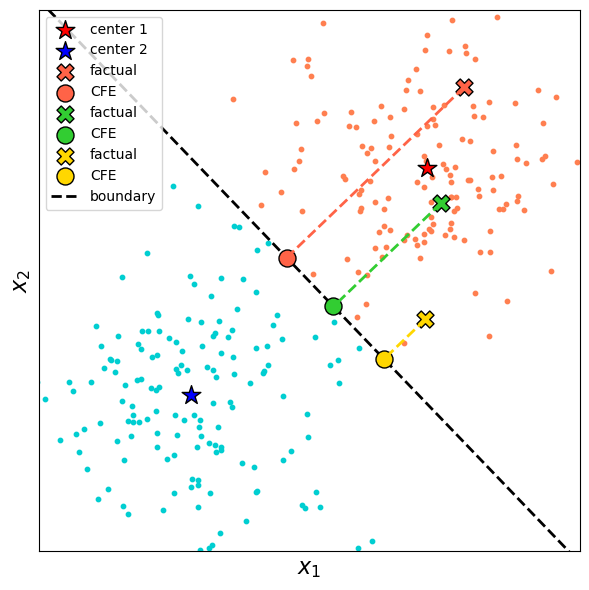

In [13]:
# Create a grid for plotting the pdfs
x, y = np.mgrid[-4:6:.01, -4:6:.01]
pos = np.dstack((x, y))

plt.figure(figsize=(6, 6))

# Scatter plots for the vectors
c_1_indexes = np.where(kmeans_labels == 1)
c_2_indexes = np.where(kmeans_labels == 0)
plt.scatter(X[c_1_indexes, 0], X[c_1_indexes, 1], s=10, c='darkturquoise', zorder=0)
plt.scatter(X[c_2_indexes, 0], X[c_2_indexes, 1], s=10, c='coral', zorder=0)

# Cluster centers
plt.scatter(m1[0], m1[1], c='r', marker='*', label='center 1', s=200, edgecolors='black')
plt.scatter(m2[0], m2[1], c='b', marker='*', label='center 2', s=200, edgecolors='black')

# --- FAR ---
factual_far = np.array([3.5, 4])
cfe_far = explainer.compute_counterfactual(factual_far, mask, d_eps_center_dist_ratio=0)
plt.scatter(factual_far[0], factual_far[1], c='tomato', marker='X', label='factual', s=150, edgecolors='black')
plt.scatter(cfe_far[0], cfe_far[1], c='tomato', marker='o', alpha=1, label='CFE', s=150, edgecolors='black')
plt.plot([factual_far[0], cfe_far[0]], [factual_far[1], cfe_far[1]], linestyle='--', color='tomato', linewidth=2)

# --- INTERMEDIATE ---
factual_interm = np.array([3.2, 2.5])
cfe_interm = explainer.compute_counterfactual(factual_interm, mask, d_eps_center_dist_ratio=0)
plt.scatter(factual_interm[0], factual_interm[1], c='limegreen', marker='X', label='factual', s=150, edgecolors='black')
plt.scatter(cfe_interm[0], cfe_interm[1], c='limegreen', marker='o', alpha=1, label='CFE', s=150, edgecolors='black')
plt.plot([factual_interm[0], cfe_interm[0]], [factual_interm[1], cfe_interm[1]], linestyle='--', color='limegreen', linewidth=2)

# --- NEAR ---
factual_near = np.array([3., 1])
cfe_near = explainer.compute_counterfactual(factual_near, mask, d_eps_center_dist_ratio=0)
plt.scatter(factual_near[0], factual_near[1], c='gold', marker='X', label='factual', s=150, edgecolors='black')
plt.scatter(cfe_near[0], cfe_near[1], c='gold', marker='o', alpha=1, label='CFE', s=150, edgecolors='black')
plt.plot([factual_near[0], cfe_near[0]], [factual_near[1], cfe_near[1]], linestyle='--', color='gold', linewidth=2)

# --- Decision boundary (orthogonal to vector between cluster centers) ---
midpoint = (m1 + m2) / 2
direction = (m2 - m1)
orthogonal_direction = np.array([-direction[1], direction[0]])
orthogonal_direction = orthogonal_direction / np.linalg.norm(orthogonal_direction)
length = 10
x_line = np.array([midpoint[0] - length * orthogonal_direction[0], 
                   midpoint[0] + length * orthogonal_direction[0]])
y_line = np.array([midpoint[1] - length * orthogonal_direction[1], 
                   midpoint[1] + length * orthogonal_direction[1]])
plt.plot(x_line, y_line, c='black', label='boundary', linewidth=2, linestyle='--', zorder=0)

# Final plot settings
plt.legend(loc='upper left')
plt.xlabel('$x_1$', fontsize=16)
plt.ylabel('$x_2$', fontsize=16)
plt.xticks([])
plt.yticks([])
plt.xlim([-2, 5])
plt.ylim([-2, 5])
plt.grid(False)
plt.tight_layout()
plt.savefig('./demo.png', dpi=500)
